In [1]:
import chipwhisperer as cw
import os, time

# (Assuming scope and target are already connected)
#bitstream_path =  r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado_\cw305_aes.runs\impl_100t\cw305_top.bit'
bitstream_path =  r'/home/sareeta/chipwhisperer/firmware/fpgas/aes/vivado_protected/cw305_aes.runs/impl_100t/cw305_top.bit'
assert os.path.isfile(bitstream_path), f"Bitstream not found: {bitstream_path}"

# 2) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()

# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", bitstream_path)
target = cw.target(scope, cw.targets.CW305, bsfile=bitstream_path, force=True)


(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.53.0) is outdated - latest is 0.54.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 994667                    to 11729526                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 7384620                   to 29538459                 
scope.clock.adc_rate                     changed from 7384620.0                 to 29538459.0               
scope.clock.clkgen_

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (/home/sareeta/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", EXP_CT.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == EXP_CT)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
# Set target round to 10 (the final round)
target.fpga_write(0x0C, [8]) 

# Run AES
target.fpga_write(target.REG_CRYPT_GO, [0x01])
time.sleep(0.01)

# Read both
ct = target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16)
snap = target.fpga_read(0x0E, 16)

print(f"Cipherout: {ct.hex().upper()}")
print(f"Snapshot : {snap.hex().upper()}")

Cipherout: 06F36A65E8A99FF8907B2E5E5DDD77DE
Snapshot : 00000000000000000000000000000000


In [6]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


In [7]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


Trace length: 5000


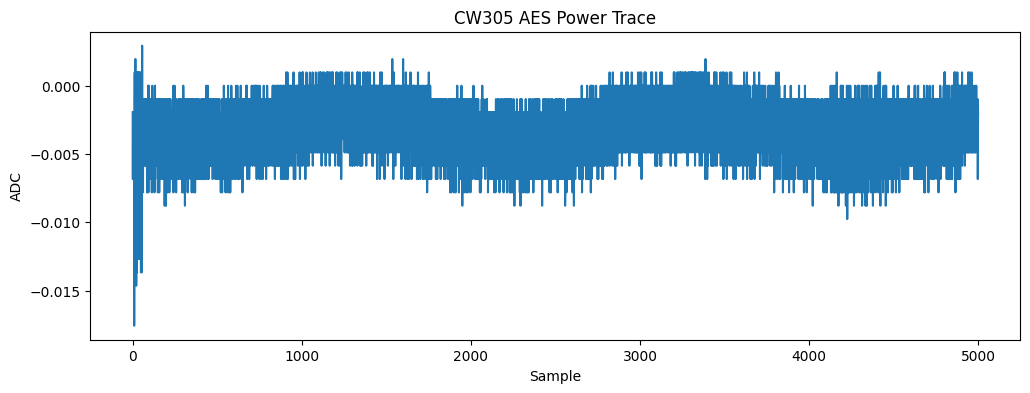

In [8]:

#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
#KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
#PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [11]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


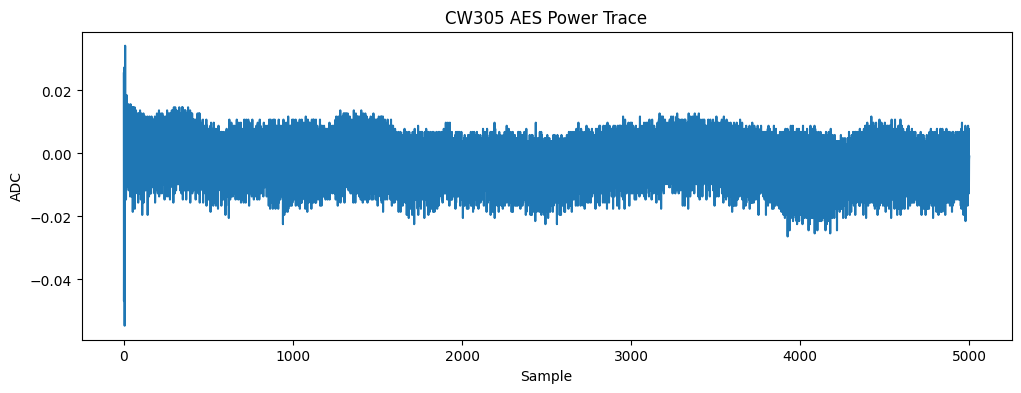

In [12]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [13]:
import numpy as np

# Convert lists to numpy arrays for efficient storage
traces_array = np.array(traces, dtype=np.float32)
pts_array = np.array([list(p) for p in pts], dtype=np.uint8)
cts_array = np.array([list(c) for c in cts], dtype=np.uint8)

# Save to a single compressed file
file_name = "normalaes_capture_10k.npz"
np.savez_compressed(file_name, 
                    traces=traces_array, 
                    pts=pts_array, 
                    cts=cts_array)

print(f"Successfully saved {len(traces)} traces to {file_name}")

Successfully saved 10000 traces to normalaes_capture_10k.npz


In [9]:
# scope.gain.gain = 46
# scope.gain.mode = "high"
# scope.adc.samples = 500
# scope.adc.offset = 0
# scope.adc.basic_mode = "rising_edge"
# scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 0
scope.trigger.triggers = "tio4"

In [8]:
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0

In [9]:
scope.glitch.trigger_src ="continuous" #"continuous" #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor"

In [10]:
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5   
print("Glitch ready.")

Glitch ready.


In [11]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

0 correct 06f36a65e8a99ff8907b2e5e5ddd77de
1 correct 06f36a65e8a99ff8907b2e5e5ddd77de
2 correct 06f36a65e8a99ff8907b2e5e5ddd77de
3 correct 06f36a65e8a99ff8907b2e5e5ddd77de
4 correct 06f36a65e8a99ff8907b2e5e5ddd77de
5 correct 06f36a65e8a99ff8907b2e5e5ddd77de
6 correct 06f36a65e8a99ff8907b2e5e5ddd77de
7 correct 06f36a65e8a99ff8907b2e5e5ddd77de
8 correct 06f36a65e8a99ff8907b2e5e5ddd77de
9 correct 06f36a65e8a99ff8907b2e5e5ddd77de


In [12]:
import numpy as np

# Configuration
N_PER_SETTING = 5
records = []
traces = []
labels = []
faults = []
hits = {"correct": 0, "faulty": 0, "no_trigger": 0}

# Range Setup
widths  = range(-49, 49, 2)
offsets = range(-49, 49, 2)

print("Starting Glitch Loop...")

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off
        
        for rep in range(N_PER_SETTING):
            # --- THE WORKING LOGIC FROM CODE 1 ---
            scope.arm()
            
            # Launch AES
            target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
            target.fpga_write(target.REG_CRYPT_GO, b"\x01")
            
            # Capture the hardware result
            cap_timeout = scope.capture()
            ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
            
            # Trace processing (from Code 2)
            tr = None
            if not cap_timeout:
                tr = np.array(scope.get_last_trace(), dtype=np.float32)
            # --------------------------------------

            # Labeling Logic
            if cap_timeout:
                label = "no_trigger"
            elif ct == EXP_CT:
                label = "correct"
            else:
                label = "faulty"
                faults.append((w, off, ct.hex()))
                print(f"FAULT! w={w} off={off} ct={ct.hex()}")

            # Store in Hits dictionary
            hits[label] += 1

            # Create the record (from Code 2)
            records.append({
                "width": w,
                "offset": off,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # Store trace if it exists
            if tr is not None:
                traces.append(tr)
                labels.append(label)

print("\n--- Scan Complete ---")
print("Summary:", hits)
print("Total records:", len(records))

Starting Glitch Loop...
FAULT! w=-39 off=1 ct=3cd1507724d524057d18cb44f812e58a
FAULT! w=-39 off=1 ct=731ecd9db6d40db174abaf18e6c7512d
FAULT! w=-27 off=1 ct=bdf37565e83d9fa8627b225e5ddc77db
FAULT! w=-25 off=1 ct=ae1c52b084ce89b0fd0776f679978e25
FAULT! w=-25 off=1 ct=64339b3e71ee49f1a7bcdfa9230a5aab
FAULT! w=-25 off=1 ct=2f7b5238c22200c178de3672dbbc220d


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:1044) Trigger not found in ADC data. No data reported!
(ChipWhisperer Scope ERROR|File OpenADC.py:866) Received fewer points than expected: 0 vs 5000
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:1044) Trigger not found in ADC data. No data reported!
(ChipWhisperer Scope ERROR|File OpenADC.py:866) Received fewer points than expected: 0 vs 5000
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invali

FAULT! w=-1 off=21 ct=8c354a90fb42ec322e9448714f71df70
FAULT! w=-1 off=35 ct=04314041e8a91fb0905a265e5c5d7352
FAULT! w=-1 off=41 ct=838d01ea2479f5402dc41fd1b59ae6e0


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08


FAULT! w=1 off=-45 ct=3a76c6b640e9b1aa66d5d9f332879e69
FAULT! w=1 off=-27 ct=c5630b0cea708bbda1ac7e789ba04c26


...

FAULT! w=9 off=43 ct=00a210def2ee591cffae52ecd8357166


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=15 off=-15 ct=b7741840b329b1649a241a77ef8eccd7


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 08
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:730) Timeout in OpenADC capture(), no t

FAULT! w=33 off=17 ct=d621048ce894ef124bf607e34e27b932
FAULT! w=39 off=11 ct=06f36a65e0a991f890792e5e5ddd75de
FAULT! w=39 off=11 ct=6734ff613d21ba06f568a4869729ec02

--- Scan Complete ---
Summary: {'correct': 11917, 'faulty': 21, 'no_trigger': 67}
Total records: 12005


In [ ]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces_3rd.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces2nd.npz")
